# California Housing model (Linear Regression and Random Forest regression via sklearn)

In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

## Importing and cleansing data 

Importing the data. Source: https://www.kaggle.com/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/data

In [9]:
data = pd.read_csv("housing.csv")
display(data.head())

print("-----Data Shape----\n")
print(data.shape)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


-----Data Shape----

(20640, 10)


Get some key features of the data.

In [11]:
print("\n-----Description-----\n")
display(data.describe())

print("\n----Information-----\n")
display(data.info())

print("\n-----Columns Name------\n")
data_1 = pd.DataFrame(data.columns, columns = ["Columns Name"])
display(data_1)



-----Description-----



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



----Information-----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


-----Columns Name------



,Columns Name
0,longitude
1,latitude
2,housing_median_age
3,total_rooms
4,total_bedrooms
5,population
6,households
7,median_income
8,median_house_value
9,ocean_proximity


Notice, for now, that there are miss data in the total_bedrooms column. We must address this.

For now, as we want to predict the median_house_value, let us first check if it has a good distribution for a better model.

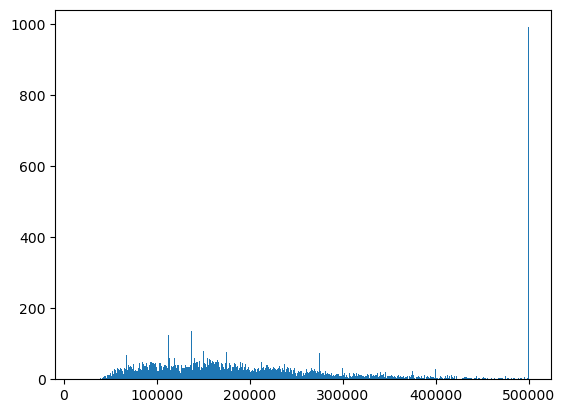

In [13]:
y0 = data["median_house_value"]
plt.hist(y0.to_numpy(), bins=1000)
plt.savefig("images/median_house_value_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [15]:
data_filter = data[data["median_house_value"] < 495000]
data_filter.shape

(19629, 10)

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [17]:
print("\n-----Before Missing Value------\n")
display(data_filter.isnull().sum())

data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)
print("\n-----After Missing Value------\n")
display(data_filter.isnull().sum())


-----Before Missing Value------



longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


-----After Missing Value------



/var/folders/yh/z6n8z11940qcsd35tldkmvvst3wtn3/T/ipykernel_21861/2158555487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Check again if the data makes sense now.

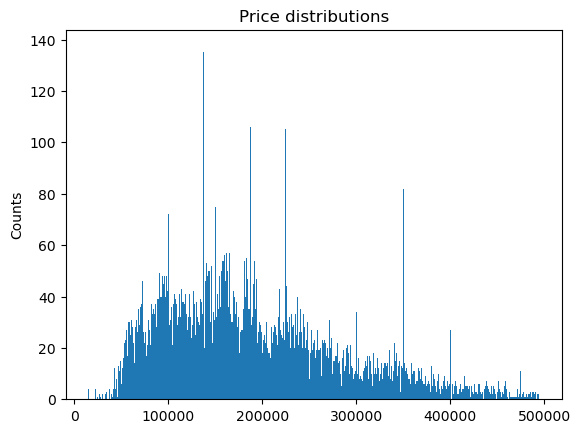

In [19]:
y = data_filter["median_house_value"]
X0 = data_filter.drop(["median_house_value"], axis =1)

plt.hist(y.to_numpy(), bins=1000)
plt.title("Price distributions")
plt.ylabel("Counts")
plt.savefig("images/median_house_value_distribution_filtered.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we want to index the data for the ocean proximity category. But first, we want to check how many unique values are there for ocean category column.

In [21]:
print("\n------unique Value-------\n")
display(X0.filter(like = "ocean_proximity").nunique())


------unique Value-------



ocean_proximity    5
dtype: int64

As there are 5 categories in this, we can index them sufficiently as follows.

In [23]:
X = pd.get_dummies(X0, columns = ["ocean_proximity"], drop_first = True)
display(X.filter(like = "ocean_proximity"))

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
20635,1,0,0,0
20636,1,0,0,0
20637,1,0,0,0
20638,1,0,0,0


Note, that the last missing one is "less than 1H from ocean". This corresponds to when the all 4 categories above are 0. Here are some plots vs the price and the histograms for the distribution of the data for each categories.

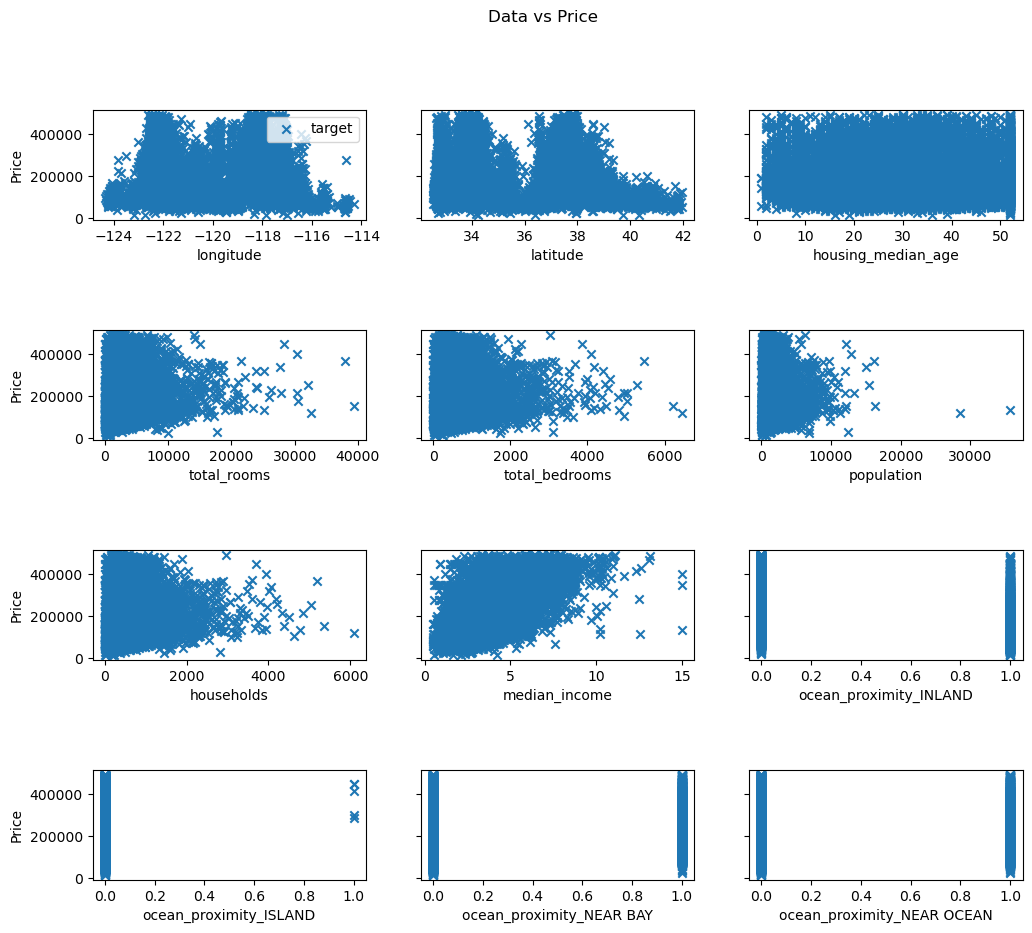

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


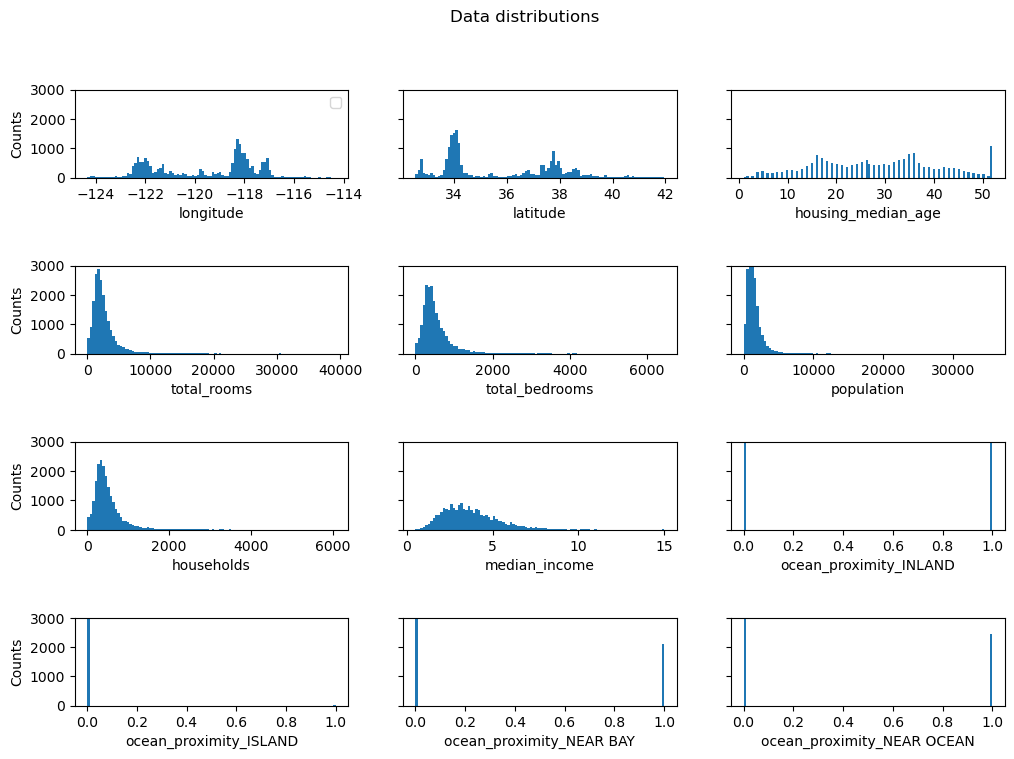

In [25]:
fig, ax = plt.subplots(4, 3, figsize=(12, 10), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X.iloc[:, i].to_numpy(), y.to_numpy(), label='target', marker = 'x')
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Data vs Price")
plt.savefig("images/data_vs_price.png", dpi=150, bbox_inches='tight') 
plt.show()

fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
plt.ylim(0,3000)
for j, i in enumerate(range(0, 12)):
    row = j//3
    col = j%3
    # Plot histogram
    ax[row, col].hist(X.iloc[:, i].to_numpy(), bins=100)
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Counts")

ax[0,0].legend()
fig.suptitle("Data distributions")
plt.savefig("images/data_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

## Spliting and Scaling

To buit the learning model, we now want to:

First, we want to split the data into training set and testing set (70:30 in for my model). This way, we can produce the model via the training set and test it with the testing set.

Second, for faster convergence, we want to rescale the data. I this model, I choose the StandarScaler (respect to its mean and standard deviation).

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)  
X_test_norm = scaler.transform(X_test) 

# Linear Regressino Model

In [30]:
sgdr = SGDRegressor(max_iter=2000)
sgdr.fit(X_train_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")
print(f"Converged: {sgdr.n_iter_ < sgdr.max_iter}")

SGDRegressor(max_iter=2000)
number of iterations completed: 6, number of weight updates: 82441.0
Converged: True


We can check the parameters here.

In [32]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [-31649.14196553 -30687.1022117    8380.83620289 -17310.82804337
  29887.89572543 -34470.00703234  24933.27534647  57270.70016668
 -24563.50433712 -90789.27883059   -618.85896541   2651.19065623], b:[189971.92927521]


Note that two are two ways you can make the prediction. Both ways should agree.

In [34]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_test_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_test_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

prediction using np.dot() and sgdr.predict match: True


Now, let us test the prediction of trained model and the testing data.

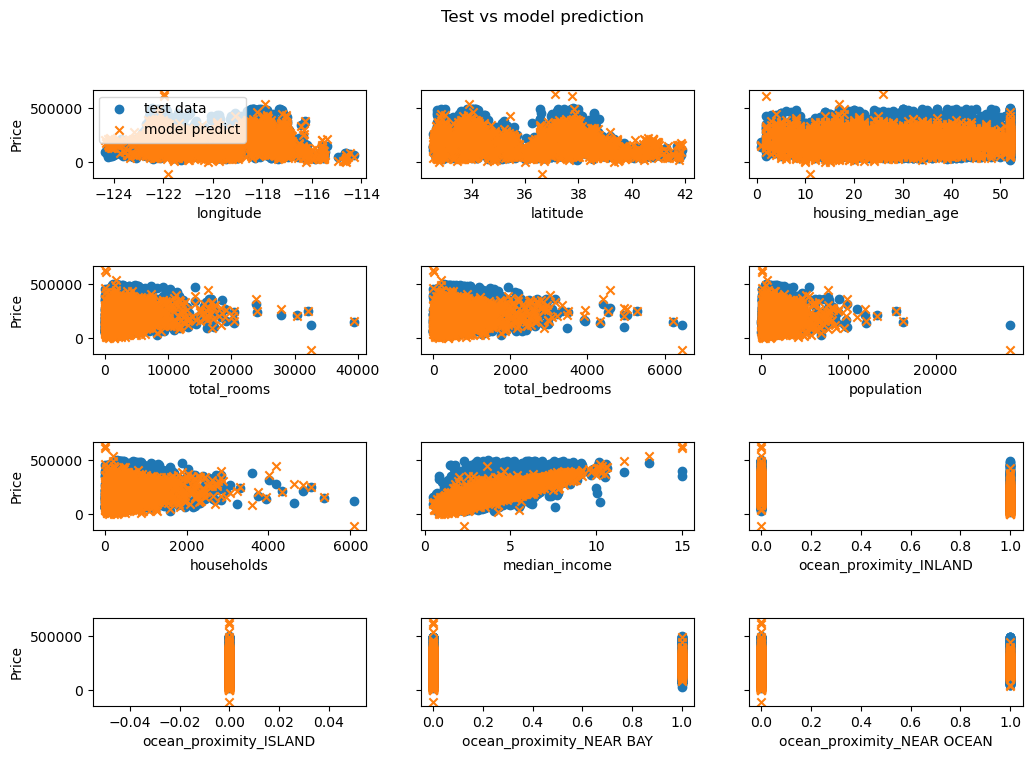

In [36]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs model prediction")
plt.savefig("images/Test_vs_model.png", dpi=150, bbox_inches='tight') 
plt.show()

That looks good. We can also quanlitatively check to see how well the model matches the data using the R2 score, given by:

In [38]:
r2_score(y_test, y_pred_sgd)

0.6144221958813175

The linear regression model only gives 61% of the R2 score. Unsuprisingly, this is because the nature of the data itself is non-linear. To further impove the prediction, let us try adding more features from existing data.

## Combining features / aggregated data

Let us consider rooms per houshold, bedrrods per rooms and population per household. Note that, since they are a ratio, I will take log of the new data to reduce skewness. 

In [42]:
X_agg = X
X_agg["rooms_per_household"] = np.log(X_agg["total_rooms"] / X_agg["households"])
X_agg["bedrooms_per_room"] = np.log(X_agg["total_bedrooms"] / X_agg["total_rooms"])
X_agg["population_per_household"] = np.log(X_agg["population"] / X_agg["households"])
X_agg["income_x_density"] = np.log(X_agg["median_income"] * (X_agg["population"] / X_agg["total_rooms"]))

display(X_agg.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,income_x_density
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0,1.943640,-1.920110,0.938270,1.113917
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0,1.830682,-1.859204,0.746613,1.032356
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0,2.114825,-2.043951,1.030426,0.897623
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0,1.760845,-1.690331,0.935287,0.904876
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0,1.837665,-1.759704,0.779998,0.289418


Let's check if the extra data set behaves normally

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


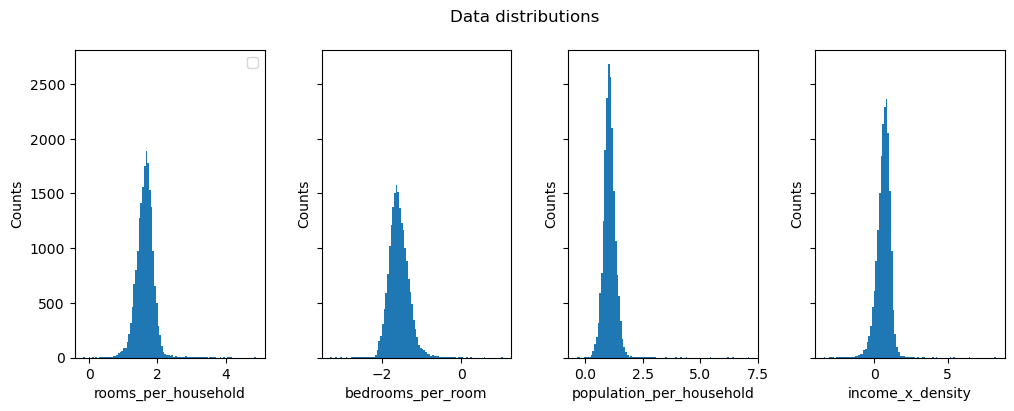

In [44]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.3)

for j, i in enumerate(range(12, 16)):
    ax[j].hist(X_agg.iloc[:, i].to_numpy(), bins=100)
    ax[j].set_xlabel(X_agg.columns[i])
    ax[j].set_ylabel("Counts")

ax[0].legend()
fig.suptitle("Data distributions")
plt.savefig("images/data_distribution_extra.png", dpi=150, bbox_inches='tight')
plt.show()

Let's redo the linear regression model

In [46]:
#Spliting and scaling
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_norm_agg = scaler.fit_transform(X_train_agg)  
X_test_norm_agg = scaler.transform(X_test_agg)

#Linear regression
sgdr_agg = SGDRegressor(max_iter=2000)
sgdr_agg.fit(X_train_norm_agg, y_train_agg)
print(sgdr_agg)
print(f"number of iterations completed: {sgdr_agg.n_iter_}, number of weight updates: {sgdr_agg.t_}")
print(f"Converged: {sgdr_agg.n_iter_ < sgdr_agg.max_iter}")

# make a prediction using sgdr.predict()
y_pred_sgd_agg = sgdr_agg.predict(X_test_norm_agg)


SGDRegressor(max_iter=2000)
number of iterations completed: 20, number of weight updates: 274801.0
Converged: True


In [47]:
# R2 score
r2_score(y_test_agg, y_pred_sgd_agg)

# Better to be explicit so it prints anywhere
print(f"Linear Regression R2 (with aggregated features): {r2_score(y_test_agg, y_pred_sgd_agg):.4f}")

Linear Regression R2 (with aggregated features): 0.6362


By aggregation, the R2 score is slighly improved with R2=0.64. However, this may be the limit of Linear regression model that cannot capture the non-linear behaviour of the date. Other model should be considered.

# Random Forest model

In this project, I would to try the Random forest model. The reason for this is that it can handle the non-linear nature of the data very weel. By randomly grouping data into numbers of trees, each tree will make a prediction of the price. The final prediction result is given by the average of all trees. 

Here, we start with 200 trees. 

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=40)
rf.fit(X_train_norm, y_train)
y_pred_rf = rf.predict(X_test_norm)
print(r2_score(y_test, y_pred_rf)) 

0.7900995895205284


Clearly, the R2 score is much improved compared to the linear regression model. However, it can be further optimised for better predictions. Before doing so, let us understand what happens inside each tree.

For each tree, the data is split at decision nodes, where the splitting feature is randomly chosen from a subset of sqrt(N) features. In our case, there are 12 features in total, such as latitude and longitude. Each decision node asks a simple yes or no question based on a threshold, for example "is median_income > 3.5?". This splitting process continues until it reaches the maximum depth, or until a node has too few samples to split further, which is controlled by the minimum samples split parameter. Once a branch can no longer split, it becomes a leaf, and the prediction at that leaf is simply the average price of all training rows that ended up there.

The final prediction for any new data point is the average of the leaf predictions across all trees.

### Optimised Random Forest model

We can therefore optimise this model with respect to the number of trees, maximum depth, and minimum samples split. This can be done using GridSearchCV, which tries every possible combination of parameters. However, since this can be quite slow for a large parameter grid, I used RandomizedSearchCV instead, which samples a fixed number of random combinations and finds a good configuration much faster.

In [55]:
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [1, 2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=40)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=24,          # only tries 20 random combinations instead of all 48
    cv=5, # 5-fold cross validation
    scoring="r2", # optimise for R2
    n_jobs=-1, # use all CPU cores to speed it up
    random_state=40 
)

random_search.fit(X_train_norm, y_train)

print("Best parameters:", random_search.best_params_)
print("Best R2 score:", random_search.best_score_)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Extracting the best configuration.

In [57]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_norm)
print("Test R2:", r2_score(y_test, y_pred_tuned))

Test R2: 0.7909081802332119


### Model insights

The best model is only slightly better R2 score than the "naive" model. Here, let see parameters inside a tree, 112th.

In [60]:
tree = best_rf.estimators_[112]

print(f"Max depth reached:     {tree.get_depth()}")
print(f"Number of leaves:      {tree.get_n_leaves()}")
print(f"Number of nodes:       {tree.tree_.node_count}")
print(f"Feature at each node:  {tree.tree_.feature}")
print(f"Threshold at each node:{tree.tree_.threshold}")

Max depth reached:     30
Number of leaves:      8543
Number of nodes:       17085
Feature at each node:  [ 7  8  7 ...  1 -2 -2]
Threshold at each node:[ 0.25346529  0.35668445 -0.6240994  ...  0.14828834 -2.
 -2.        ]


Now, let's look into the Random Forest model and how each feature contributes to the model via Feature importance. The feature importance tells you that which feature gives the error reduction the most (mean square error in this model). That is, it tells you what data you should be looking at to make a well prediction.

                       Feature  Importance
7                median_income    0.436334
8       ocean_proximity_INLAND    0.161114
0                    longitude    0.118194
1                     latitude    0.110654
2           housing_median_age    0.048045
5                   population    0.036683
3                  total_rooms    0.029005
4               total_bedrooms    0.025589
6                   households    0.021999
11  ocean_proximity_NEAR OCEAN    0.010667
10    ocean_proximity_NEAR BAY    0.000997
9       ocean_proximity_ISLAND    0.000720


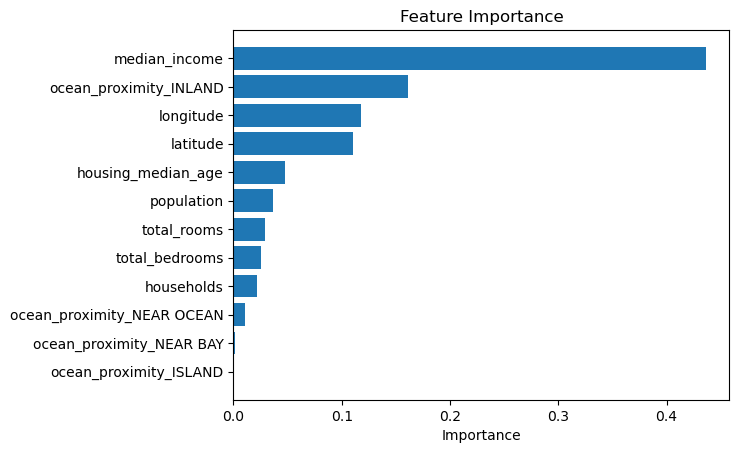

In [62]:
importances = best_rf.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

That is the median income highly contributes to the accurate model. Note that there may be biases towards unique features like ocean proximity as these are registered only 0 and 1.

Let's visualise the random forest model with the test data.

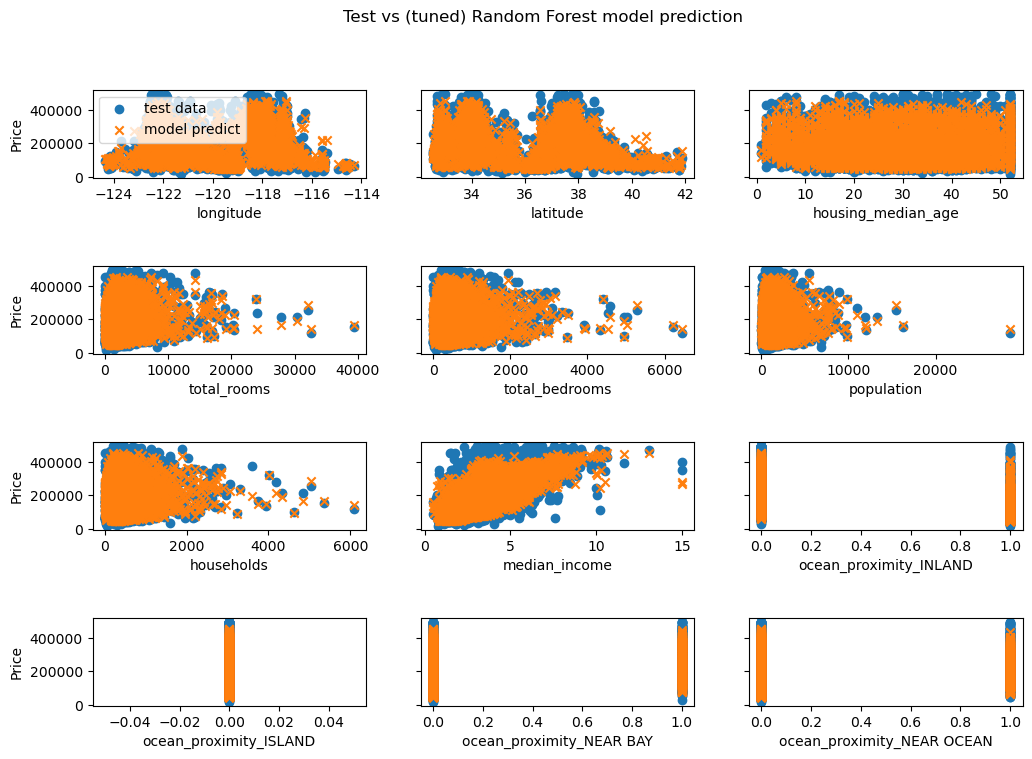

In [64]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred_tuned, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs (tuned) Random Forest model prediction")
plt.savefig("images/Test_vs_model_rf.png", dpi=150, bbox_inches='tight') 
plt.show()

## Let's also try with aggregated data.

Here, I will use the parameters found in the optimisation.

### Random forest with featured engineer.

In [68]:
rf_agg = RandomForestRegressor(n_estimators=200, random_state=40)
rf_agg.fit(X_train_norm_agg, y_train_agg)
y_pred_rf_agg = rf_agg.predict(X_test_norm_agg)
print(r2_score(y_test_agg, y_pred_rf_agg))

0.7854286791529049


In [69]:
importances = rf_agg.feature_importances_
feature_names = X_train_agg.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

                       Feature  Importance
7                median_income    0.416840
8       ocean_proximity_INLAND    0.160871
14    population_per_household    0.110477
0                    longitude    0.074372
1                     latitude    0.068054
2           housing_median_age    0.039890
13           bedrooms_per_room    0.025554
12         rooms_per_household    0.025386
15            income_x_density    0.023427
3                  total_rooms    0.014126
4               total_bedrooms    0.012826
5                   population    0.012204
6                   households    0.011206
11  ocean_proximity_NEAR OCEAN    0.003506
10    ocean_proximity_NEAR BAY    0.000983
9       ocean_proximity_ISLAND    0.000277


It is seen that adding the aggregated data doesn't improve the random forrest model. This may be becuase the non-linearity from the aggreated data has been discovered by the model itself, and it doesn't need more from the data aggregation.

## Residual Analysis

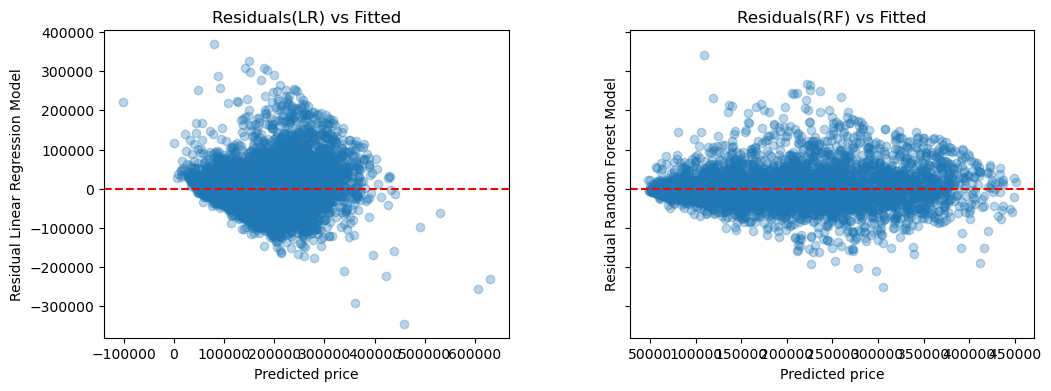

In [72]:
residuals_LR = y_test - y_pred # For Linear regression model
residuals_RF = y_test - y_pred_tuned # For random forest model

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.3)

ax[0].scatter(y_pred, residuals_LR, alpha=0.3)
ax[0].set_xlabel("Predicted price")
ax[0].set_ylabel("Residual Linear Regression Model")
ax[0].set_title("Residuals(LR) vs Fitted")
ax[0].axhline(0, color='red', linestyle='--')

ax[1].scatter(y_pred_tuned, residuals_RF, alpha=0.3)
ax[1].set_xlabel("Predicted price")
ax[1].set_ylabel("Residual Random Forest Model")
ax[1].set_title("Residuals(RF) vs Fitted")
ax[1].axhline(0, color='red', linestyle='--')

plt.savefig("images/residuals_vs_fitted.png", dpi=150)
plt.show()

The linear regression doesn't look good when estimating extreme price. It over-predicts the high price and under-predicts the low price.  There are no obvious patterns for the Random Forest model, making the model more reliable!

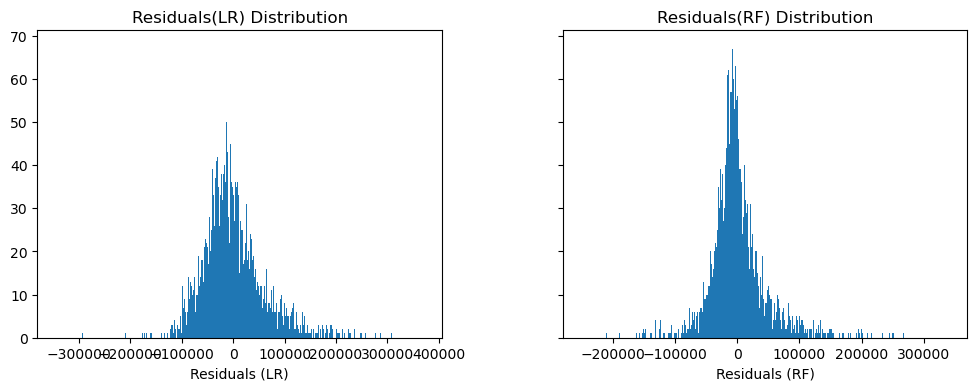

Mean residual(LR): 564.0
Std of residuals(LR): 60704.5
Mean residual(RF): 165.2
Std of residuals(RF): 44704.3


In [74]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.3)

ax[0].hist(residuals_LR, bins=1000)
ax[0].set_xlabel("Residuals (LR)")
ax[0].set_title("Residuals(LR) Distribution")

ax[1].hist(residuals_RF, bins=1000)
ax[1].set_xlabel("Residuals (RF)")
ax[1].set_title("Residuals(RF) Distribution")

plt.savefig("images/residual_distribution.png", dpi=150)
plt.show()

print(f"Mean residual(LR): {residuals_LR.mean():.1f}")
print(f"Std of residuals(LR): {residuals_LR.std():.1f}")
print(f"Mean residual(RF): {residuals_RF.mean():.1f}")
print(f"Std of residuals(RF): {residuals_RF.std():.1f}")

Both have their resuduals with a "normal" distribution and centered at zero. This is good. Let's also see top 15th worst prediction.

In [76]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
## Linear regression model
error_df["predicted_LR"] = y_pred
error_df["abs_error_LR"] = np.abs(residuals_LR.values)
## Random forest
error_df["predicted_RF"] = y_pred_tuned
error_df["abs_error_RF"] = np.abs(residuals_RF.values)

print("-----Worst prediction (LR)----\n")
print(error_df.sort_values("abs_error_LR", ascending=False).head(10))

-----Worst prediction (LR)----

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
19542    -120.92     37.63                39.0         45.0             8.0   
4492     -118.22     34.06                52.0         48.0             6.0   
6452     -118.05     34.12                20.0       5218.0           959.0   
10616    -117.81     33.69                 5.0       1256.0           256.0   
6376     -118.03     34.15                43.0       1694.0           283.0   
14460    -117.27     32.85                34.0       2105.0           444.0   
15856    -122.38     37.76                52.0        248.0            68.0   
4548     -118.21     34.02                52.0         22.0             7.0   
489      -122.25     37.86                48.0       2153.0           517.0   
18346    -122.15     37.43                20.0      11709.0           436.0   

       population  households  median_income  ocean_proximity_INLAND  \
19542        22.0         

In [77]:
print("-----Worst prediction (RF)----\n")
print(error_df.sort_values("abs_error_RF", ascending=False).head(10))

-----Worst prediction (RF)----

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
19542    -120.92     37.63                39.0         45.0             8.0   
14460    -117.27     32.85                34.0       2105.0           444.0   
489      -122.25     37.86                48.0       2153.0           517.0   
6452     -118.05     34.12                20.0       5218.0           959.0   
6376     -118.03     34.15                43.0       1694.0           283.0   
15651    -122.41     37.79                52.0       2302.0           938.0   
10616    -117.81     33.69                 5.0       1256.0           256.0   
10766    -117.90     33.63                26.0       1632.0           376.0   
15856    -122.38     37.76                52.0        248.0            68.0   
6702     -118.13     34.13                39.0       2099.0           397.0   

       population  households  median_income  ocean_proximity_INLAND  \
19542        22.0         

In [78]:
residuals = y_test - y_pred_tuned

It seems that the worst predictions for both models are from a big city. 

For example, -122.15, 37.43  => San Jose, -118.22, 34.06 ==> LA..

Let us check the geographical map for the absolute error.

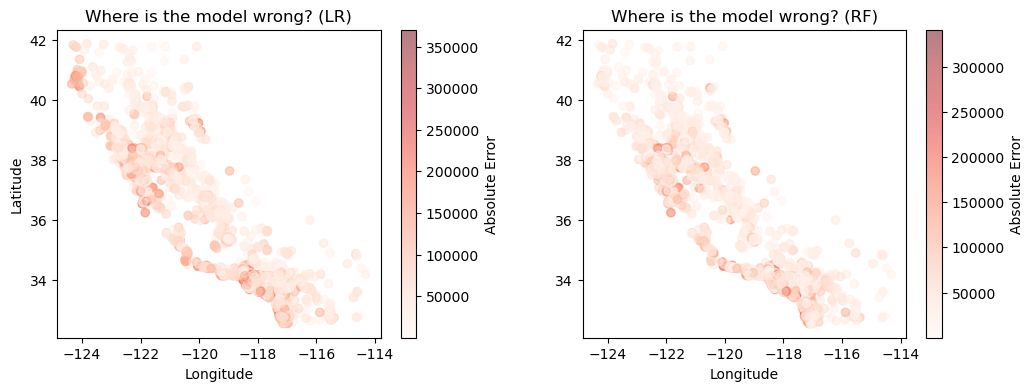

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)

sc0 = ax[0].scatter(
    error_df["longitude"], error_df["latitude"],
    c=error_df["abs_error_LR"], cmap="Reds", alpha=0.5
)
ax[0].set_title("Where is the model wrong? (LR)")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
plt.colorbar(sc0, ax=ax[0], label="Absolute Error")

sc1 = ax[1].scatter(
    error_df["longitude"], error_df["latitude"],
    c=error_df["abs_error_RF"], cmap="Reds", alpha=0.5
)
ax[1].set_title("Where is the model wrong? (RF)")
ax[1].set_xlabel("Longitude")
plt.colorbar(sc1, ax=ax[1], label="Absolute Error")

plt.savefig("images/error_map.png", dpi=150, bbox_inches='tight')
plt.show()

Let's see if we can aggregate data based on the distance from the big cities.

In [82]:
# Distance to San Francisco
X_agg["dist_sf"] = np.sqrt((X_agg["latitude"] - 37.77)**2 + (X_agg["longitude"] - (-122.42))**2)

# Distance to Los Angeles
X_agg["dist_la"] = np.sqrt((X_agg["latitude"] - 34.05)**2 + (X_agg["longitude"] - (-118.24))**2)

# Distance to San Diego
X_agg["dist_sd"] = np.sqrt((X_agg["latitude"] - 32.72)**2 + (X_agg["longitude"] - (-117.15))**2)

display(X_agg.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household,income_x_density,dist_sf,dist_la,dist_sd
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0,1.943640,-1.920110,0.938270,1.113917,0.219545,5.530732,7.240994
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0,1.830682,-1.859204,0.746613,1.032356,0.219317,5.509673,7.219730
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0,2.114825,-2.043951,1.030426,0.897623,0.196977,5.517246,7.226687
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0,1.760845,-1.690331,0.935287,0.904876,0.187883,5.524500,7.233733
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0,1.837665,-1.759704,0.779998,0.289418,0.187883,5.524500,7.233733


### Aggregation from big city feature 

Linear Regression

In [84]:
#Spliting and scaling
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_norm_agg = scaler.fit_transform(X_train_agg)  
X_test_norm_agg = scaler.transform(X_test_agg)

#Linear regression
sgdr_agg = SGDRegressor(max_iter=2000)
sgdr_agg.fit(X_train_norm_agg, y_train_agg)
print(sgdr_agg)
print(f"number of iterations completed: {sgdr_agg.n_iter_}, number of weight updates: {sgdr_agg.t_}")
print(f"Converged: {sgdr_agg.n_iter_ < sgdr_agg.max_iter}")

# make a prediction using sgdr.predict()
y_pred_sgd_agg = sgdr_agg.predict(X_test_norm_agg)

# R2 score
r2_score(y_test_agg, y_pred_sgd_agg)

# Better to be explicit so it prints anywhere
print(f"Linear Regression R2 (with aggregated features): {r2_score(y_test_agg, y_pred_sgd_agg):.4f}")

SGDRegressor(max_iter=2000)
number of iterations completed: 6, number of weight updates: 82441.0
Converged: True
Linear Regression R2 (with aggregated features): 0.6412


That's improved!!

### Random Forest model

In [86]:
rf_agg = RandomForestRegressor(n_estimators=200, random_state=40)
rf_agg.fit(X_train_norm_agg, y_train_agg)
y_pred_rf_agg = rf_agg.predict(X_test_norm_agg)
print(r2_score(y_test_agg, y_pred_rf_agg))

0.8030256998882488


In [87]:
importances = rf_agg.feature_importances_
feature_names = X_train_agg.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

                       Feature  Importance
7                median_income    0.411109
8       ocean_proximity_INLAND    0.160871
14    population_per_household    0.103097
17                     dist_la    0.041692
1                     latitude    0.041464
16                     dist_sf    0.041009
0                    longitude    0.035980
2           housing_median_age    0.030042
12         rooms_per_household    0.023724
18                     dist_sd    0.021982
13           bedrooms_per_room    0.021892
15            income_x_density    0.020366
3                  total_rooms    0.012167
4               total_bedrooms    0.010413
5                   population    0.009853
6                   households    0.009469
11  ocean_proximity_NEAR OCEAN    0.003744
10    ocean_proximity_NEAR BAY    0.000793
9       ocean_proximity_ISLAND    0.000331


Including the distance from big city feature improves the model, especially the distance from LA with feature importance of 0.04. Let's optimise the Random Forest model.

In [89]:
param_grid = {
    "n_estimators": [200, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [1, 2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=40)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=24,          # only tries 20 random combinations instead of all 48
    cv=5, # 5-fold cross validation
    scoring="r2", # optimise for R2
    n_jobs=-1, # use all CPU cores to speed it up
    random_state=40 
)

random_search.fit(X_train_norm_agg, y_train_agg)

print("Best parameters:", random_search.best_params_)
print("Best R2 score:", random_search.best_score_)

best_rf = random_search.best_estimator_

y_pred_tuned_2 = best_rf.predict(X_test_norm_agg)
print("Test R2:", r2_score(y_test, y_pred_tuned_2))

Best parameters: {'n_estimators': 500, 'min_samples_split': 1, 'max_depth': 30}
Best R2 score: 0.7944455601943611
Test R2: 0.8038414575019791


In [133]:
importances = best_rf.feature_importances_
feature_names = X_train_agg.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

                       Feature  Importance
7                median_income    0.410830
8       ocean_proximity_INLAND    0.161164
14    population_per_household    0.102721
17                     dist_la    0.041778
1                     latitude    0.041330
16                     dist_sf    0.041008
0                    longitude    0.036200
2           housing_median_age    0.029791
12         rooms_per_household    0.023745
18                     dist_sd    0.022127
13           bedrooms_per_room    0.021915
15            income_x_density    0.020646
3                  total_rooms    0.012048
4               total_bedrooms    0.010546
5                   population    0.009872
6                   households    0.009369
11  ocean_proximity_NEAR OCEAN    0.003681
10    ocean_proximity_NEAR BAY    0.000852
9       ocean_proximity_ISLAND    0.000378


# Conclusion

In this project, I built and compared two models, Linear Regression and Random Forest, to predict median house prices in California. I began by cleaning the data, which involved filtering out extreme values near the $500,000 cap and filling missing values in the `total_bedrooms` column with the column median.

Linear Regression achieved an R2 score of 61%, which serves as a reasonable baseline. Adding ratio-based aggregated features such as rooms per household and population per household improved this slightly to 64%, as these derived ratios help capture some non-linear relationships that a linear model cannot learn on its own. Switching to Random Forest improved the R2 score significantly to 79.1%. This is expected, as the relationship between features and house price is non-linear in nature, which Random Forest handles well through its ensemble of decision trees. Notably, adding the same ratio features did not improve the Random Forest model, since it can already discover these relationships implicitly through sequential splits on the underlying features.

To understand where the models were failing, I conducted a residual analysis. The residuals for both models are centred around zero with a roughly normal distribution, which is a healthy sign. However, plotting the absolute errors geographically revealed that the worst predictions are concentrated around major cities, particularly San Francisco and Los Angeles, where prices are more volatile and harder to predict from the available features alone.

This finding motivated a further round of feature engineering, adding Euclidean distance features to San Francisco, Los Angeles, and San Diego. Unlike the ratio features, these city distance features carry genuinely new geographic information that latitude and longitude alone do not fully capture. The distance to Los Angeles in particular showed a feature importance of 0.04 in the Random Forest, confirming it added meaningful signal. With this addition and further hyperparameter tuning using RandomizedSearchCV, the final model reached an R2 score of 80.4%.

Looking inside the model via feature importance, median income remains the strongest predictor by a significant margin, accounting for 41.1% of the model's decisions. Location features, including latitude, longitude, and city distances, are the next most influential, which makes intuitive sense given how strongly neighbourhood affects property value.

To improve the model further, one could explore gradient boosting approaches such as XGBoost, which often outperform Random Forest on structured tabular data by building trees sequentially, each correcting the errors of the previous. Additional location-based features, such as distance to the coastline or proximity to employment clusters, may also help given how strongly geography drives housing prices in California. The tradeoff, however, is greater computational complexity and longer training time.